In [1]:
import openai
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import  WikipediaAPIWrapper

In [2]:
# Wikipedia Tool
wiki_api_wrapper = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
tool = WikipediaQueryRun(api_wrapper=wiki_api_wrapper)


In [3]:
from langchain.chat_models import init_chat_model
llm = init_chat_model('groq:qwen/qwen3-32b')

In [4]:
class AgentState (TypedDict):
    messages : Annotated[list[AnyMessage],operator.add]

In [57]:
class Agent:
    def __init__(self,model,tools,system= "",checkpointer=None):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm",self.llm_call)
        graph.add_node("action",self.take_action)
        graph.add_conditional_edges("llm",self.exists_action,{
            True:"action",
            False: END
        })
        graph.add_edge("llm","action")
        graph.set_entry_point("llm")
        self.graph = graph.compile(checkpointer=checkpointer,interrupt_before=["action"])
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)
    
    def llm_call(self,state:AgentState):
        message = state["messages"]
        if self.system:
            message = [SystemMessage(content=self.system)] + message
        response = self.model.invoke(message)
        return {"messages":[response]}
        
    def take_action(self,state:AgentState):
        tool_calls = state["messages"][-1].tool_calls
        results = []
        # for t in tools:
        #     result = self.tools[t['name']].invoke(t['args'])
        #     results.append(ToolMessage(content=result,tool_call_id=t["id"],name=t["name"]))
        # return {'messages':results}
        for t in tool_calls:
            tool_name = t['name']
            tool_args = t['args'] # This is usually a dict: {"query": "..."}
        
        # Look up the tool in your dictionary
            tool_instance = self.tools[tool_name]
        
        # FIX: Most tools expect the dict unpacked or a specific key
        # If your tool has one arg, pass the value. If many, pass the dict.
            try:
                # If it's a standard LangChain tool, .invoke(tool_args) is usually fine,
                # but let's ensure 'result' is a string.
                result = tool_instance.invoke(tool_args)
                
                # Ensure result is a string, not a list or set
                content = str(result)
                
                results.append(ToolMessage(
                    content=content,
                    tool_call_id=t["id"],
                    name=tool_name
                ))
            except Exception as e:
                results.append(ToolMessage(
                    content=f"Error: {str(e)}",
                    tool_call_id=t["id"],
                    name=tool_name
                ))
                
        return {'messages': results}
    
    def exists_action(self,state:AgentState):
        messages = state["messages"][-1]
        return len(messages.tool_calls) > 0



Persistence & Memory

In [12]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
conn = sqlite3.connect("agent_memory.db",check_same_thread=False)
memory = SqliteSaver(conn=conn)

In [58]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

agent = Agent(llm,[tool],prompt,checkpointer=memory)

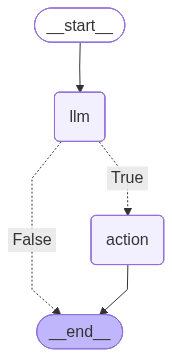

In [14]:
agent.graph

In [36]:
messages = [HumanMessage(content="Whats your name?")]
agent.graph.invoke({"messages":messages})

{'messages': [HumanMessage(content='Whats your name?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='My name is Qwen. I am a large-scale language model developed by Tongyi Lab. How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "Whats your name?" Let me think about how to respond.\n\nFirst, I need to remember that I\'m Qwen, the language model developed by Tongyi Lab. But the user might not know that. They want to know my name. The correct answer is to state my name clearly. \n\nWait, do I need to use any tools here? The tools provided include a Wikipedia function. But the question is straightforward and doesn\'t require looking up information. My name is a basic fact that I should know without needing to search. So no need to call any functions here. Just respond directly with my name. \n\nMake sure the response is friendly and concise. Let me check if there\'s any other info needed, but the user just wants the name. So

In [ ]:
messages = [HumanMessage(content="Hi Quen. Where do you stay?")]
response = agent.graph.invoke({"messages":messages})

In [41]:
response["messages"][-1]

AIMessage(content="I don't have a physical location since I'm an AI language model, but I'm hosted online and can be accessed from anywhere in the world. My developers at Alibaba Cloud are based in Hangzhou, China. Is there something specific you'd like to know?", additional_kwargs={'reasoning_content': 'Okay, the user asked, "Hi Quen. Where do you stay?" First, I need to understand what they\'re asking. Since I\'m an AI, I don\'t have a physical location. But maybe they want to know where my servers are located or where the company that created me is based.\n\nI should check if there\'s any official information about the company\'s headquarters. The user might be referring to Quen, which could be a name they gave me, but I\'m not sure. Let me think—maybe they meant "Quen" as a name, but I\'m actually Qwen. Maybe a typo. Anyway, focusing on the question: where do I "stay"? Since I\'m an AI, I don\'t have a physical presence. But the company behind me, Tongyi Lab, is part of Alibaba Gro

In [40]:
messages = [HumanMessage(content="What is WikiPedia and what information does it provide?")]
thread = {"configurable": {"thread_id": "2"}}

In [74]:
for event in agent.graph.stream({"messages": messages}, thread):
    # event is a dict, e.g., {"rag_node": {"messages": [...]}}
    for node_name, state_update in event.items():
        # Check if 'messages' is actually in the update
        if "messages" in state_update:
            last_message = state_update["messages"][-1]
            print(f"Node [{node_name}]: {last_message.content},Tool Calls: {last_message.tool_calls}")

Node [llm]: Hello! 😊 I exist entirely in a digital environment, so I don’t have a physical "home" like humans do. I’m powered by servers and run on cloud infrastructure, which means I’m always online and ready to chat! 🌐 Think of me as a cloud dweller. How about you—where are you from? 🌎,Tool Calls: []


In [77]:
agent.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='What is WikiPedia and what information does it provide?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking what Wikipedia is and what information it provides. I need to explain both aspects. First, I should define Wikipedia as an online encyclopedia. Then mention that it\'s a multilingual, collaborative project where anyone can edit and contribute. For the information part, I should list the types of content it covers—like people, places, history, science, technology, culture, etc. Also, note that it\'s free to access and has a vast number of articles. Maybe include some examples of topics covered. Wait, do I need to check if there\'s a Wikipedia page about itself? The user might be curious about its structure or history. But the question is more about what it is and what it provides, so focusing on the scope and nature of the information is key. 

In [60]:
agent.graph.get_state(thread).next

('action',)

In [79]:
states = []
for state in agent.graph.get_state_history(thread):
    states.append(state)

In [80]:
states

[StateSnapshot(values={'messages': [HumanMessage(content='What is WikiPedia and what information does it provide?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking what Wikipedia is and what information it provides. I need to explain both aspects. First, I should define Wikipedia as an online encyclopedia. Then mention that it\'s a multilingual, collaborative project where anyone can edit and contribute. For the information part, I should list the types of content it covers—like people, places, history, science, technology, culture, etc. Also, note that it\'s free to access and has a vast number of articles. Maybe include some examples of topics covered. Wait, do I need to check if there\'s a Wikipedia page about itself? The user might be curious about its structure or history. But the question is more about what it is and what it provides, so focusing on the scope and nature of the information is key.

In [25]:
messages = [HumanMessage(content="When was WikiPedia founded?")]
thread = {"configurable": {"thread_id": "1"}}
for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content='Wikipedia was founded on **January 15, 2001**, by **Jimmy Wales** and **Larry Sanger**. It began as a free, collaborative online encyclopedia with the goal of making knowledge accessible to all. The platform has since grown into one of the most comprehensive and widely used reference sources in the world.', additional_kwargs={'reasoning_content': 'Okay, the user is asking when Wikipedia was founded. I need to find the founding date. I remember that Wikipedia is a wiki-based encyclopedia, but I don\'t have the exact date in my head. Since the user has asked about Wikipedia before, maybe the previous tool call can help. Wait, in the history, there\'s a tool call where I used the Wikipedia function to look up "Wikipedia" itself. Let me check that.\n\nLooking at the history, when the user asked "What is WikiPedia and what information does it provide?", I called the Wikipedia function with the query "Wikipedia". The response from that tool call probably incl

In [ ]:
messages = [HumanMessage(content="Which one is warmer?")]
thread = {"configurable": {"thread_id": "2"}}
for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        print(v)

In [30]:
agent.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}), AIMessage(content="The Wikipedia tool is designed for general knowledge and historical data, but it doesn't provide real-time weather information. I recommend checking a weather service like Weather.com or a weather app for the current conditions in San Francisco.", additional_kwargs={'reasoning_content': "Okay, the user is asking for the weather in San Francisco. Let me check the tools available. The only tool provided is the Wikipedia wrapper. Hmm, but Wikipedia isn't typically used for real-time weather data. The tool's description says it's useful for general questions, but weather is more of a current condition rather than a general fact. Since there's no weather tool available, I can't provide real-time info. I should inform the user that I can't access current weather data and suggest checking a weather service or app.\n"}, response_metadata={'token_

In [ ]:
agent.graph.nodes

{'__start__': <langgraph.pregel._read.PregelNode at 0x24a8441c440>,
 'llm': <langgraph.pregel._read.PregelNode at 0x24a84b4a350>,
 'action': <langgraph.pregel._read.PregelNode at 0x24a84b49f90>}

Langchain Agent Functions

In [82]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import  WikipediaAPIWrapper
# Wikipedia Tool
wiki_api_wrapper = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_api_wrapper)



In [126]:
from langchain.agents.middleware import ModelCallLimitMiddleware, ToolCallLimitMiddleware
# Tried with 0 to see if it works without any limits. You can set it to a positive integer to limit the number of calls.
modelmiddleware = ModelCallLimitMiddleware(run_limit=1,thread_limit=2)
toolmiddleware = ToolCallLimitMiddleware(run_limit=0,thread_limit=0)

In [127]:
wiki_agent = create_agent(llm,
                     tools= [wiki_tool],
                    system_prompt="You are a smart assistant. Use the tools to look up information.",
                    middleware=[modelmiddleware,toolmiddleware])

In [128]:
wiki_agent.invoke({"messages": "What is WikiPedia and what information does it provide?"},
                  config={"configurable": {"thread_id": "2"}})

{'messages': [HumanMessage(content='What is WikiPedia and what information does it provide?', additional_kwargs={}, response_metadata={}, id='d1ecf111-d91d-47cc-9e42-68df6d7cc357'),
  AIMessage(content="Wikipedia is a free, open-source, multilingual online encyclopedia that allows collaborative editing of its content. It provides information on a vast range of topics, including people, places, companies, historical events, scientific concepts, cultural works, and more. The platform emphasizes neutrality, verifiability, and comprehensive coverage, with content created and maintained by volunteers worldwide. Information is organized into articles, often with citations to authoritative sources, though users are encouraged to verify critical details for accuracy.\n\nWould you like me to retrieve specific details about Wikipedia's structure, history, or policies using the tool?", additional_kwargs={'reasoning_content': "Okay, the user is asking what Wikipedia is and what information it prov

In [129]:
wiki_agent.invoke({"messages": "When was Wikipedia founded?"},
                  config={"configurable": {"thread_id": "1"}})

{'messages': [HumanMessage(content='When was Wikipedia founded?', additional_kwargs={}, response_metadata={}, id='1f1e5caa-1cbe-4c22-90c5-fd8fc9809942'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking when Wikipedia was founded. I need to find the founding date. Since Wikipedia is a well-known entity, I can use the Wikipedia function provided. The function requires a search query. The query should be "Wikipedia" to look up its own page. I\'ll call the function with that query to get the necessary information.\n', 'tool_calls': [{'id': 'xg1bnm4pk', 'function': {'arguments': '{"query":"Wikipedia"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 206, 'total_tokens': 302, 'completion_time': 0.173417289, 'completion_tokens_details': {'reasoning_tokens': 71}, 'prompt_time': 0.009124954, 'prompt_tokens_details': None, 'queue_time': 0.047075406, 'total_time': 0.182542243}, 'mo

In [106]:
wiki_agent.invoke({"messages": "What is the capital of France?"},
                  config={"configurable": {"thread_id": "1"}})

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='e524d17a-4157-4e00-9b6c-7161e535af85'),
  AIMessage(content='The capital of France is Paris.', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the capital of France. I need to provide an accurate answer. I remember that France\'s capital is Paris, but I should verify this to be sure. Let me use the Wikipedia tool to check. I\'ll search for "France" on Wikipedia. Looking at the information, it should clearly state Paris as the capital. Once confirmed, I can confidently tell the user that Paris is the capital of France.\n'}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 208, 'total_tokens': 308, 'completion_time': 0.213498601, 'completion_tokens_details': {'reasoning_tokens': 88}, 'prompt_time': 0.008722212, 'prompt_tokens_details': None, 'queue_time': 0.047552222, 'total_time': 0.222220813}, 'model_name': 'qwen/qwen3-3

In [107]:
wiki_agent.invoke({"messages": "What is the capital of India?"},
                  config={"configurable": {"thread_id": "1"}})

{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='7eb7e11b-316b-491e-97e0-d74a8aff3879'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the capital of India. I need to provide an accurate answer. Let me recall what I know. I think the capital is New Delhi. But to be sure, I should verify this. Since I have access to Wikipedia, I can use the wikipedia function to look it up. The function requires a search query. The query should be "capital of India". Let me execute that. The result from Wikipedia will confirm if New Delhi is indeed the capital. Once confirmed, I can present the answer to the user with confidence.\n', 'tool_calls': [{'id': '2nvahwzye', 'function': {'arguments': '{"query":"capital of India"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_tokens': 208, 'total_tokens': 346, 'completion_time': 

Async Persistence

In [ ]:
from langgraph.checkpoint.aiosqlite import AsyncSqliteSaver

memory = AsyncSqliteSaver.from_conn_string(":memory:")
abot = Agent(model, [tool], system=prompt, checkpointer=memory)

In [ ]:
messages = [HumanMessage(content="What is the weather in SF?")]
thread = {"configurable": {"thread_id": "4"}}
async for event in abot.graph.astream_events({"messages": messages}, thread, version="v1"):
    kind = event["event"]
    if kind == "on_chat_model_stream":
        content = event["data"]["chunk"].content
        if content:
            # Empty content in the context of OpenAI means
            # that the model is asking for a tool to be invoked.
            # So we only print non-empty content
            print(content, end="|")

Caching Sample

In [ ]:
import redis
import json
import hashlib

class GraphInstance:
    def __init__(self):
        # ... your existing init ...
        self.redis_client = redis.Redis(host='localhost', port=6379, db=0, decode_responses=True)
        self.graph = self.workflow()

    def cache_node(self, state: MessagesState):
        user_message = state["messages"][-1].content
        # Create a unique key based on the question (hashing prevents long-key issues)
        query_hash = hashlib.md5(user_message.lower().strip().encode()).hexdigest()
        cache_key = f"chat_cache:{query_hash}"

        cached_answer = self.redis_client.get(cache_key)
        
        if cached_answer:
            get_logger("Graph").info("Cache Hit! Returning saved answer.")
            # We return a Command to skip the RAG agent and go straight to END
            return {
                "messages": [AIMessage(content=cached_answer + " (Cached)")],
            }
        
        # If no cache, we do nothing and let the graph move to the next node
        return {"messages": []}

    def workflow(self):
        builder = StateGraph(MessagesState)
        
        # Add the cache check as the FIRST node
        builder.add_node("check_cache", self.cache_node)
        builder.add_node("rag_agent", self.rag_node)
        
        builder.add_edge(START, "check_cache")
        
        # Logic: If cache_node added an AIMessage, it means we found an answer.
        # Otherwise, go to the RAG agent.
        builder.add_conditional_edges(
            "check_cache",
            lambda state: END if any(isinstance(m, AIMessage) for m in state["messages"][-1:]) else "rag_agent"
        )
        
        return builder.compile(checkpointer=self.memory)